In [22]:
# Cell 1: Imports & style
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

PROJECT_ROOT = Path('.').resolve().parent
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\hayk_\OneDrive\Desktop\05_LMU_Masters\04_applied_dl\adl_last\adl-bnn-textgen


In [23]:
# Cell 2: Load LLM Judge results (8 new models)
# Labels encode: sampler-prior-learningRate
# SGHMC runs: 5e-6 and 1e-5
# BAOA runs:  1e-6 and 5e-6

llm_raw = [
    {'label': 'SGHMC-PP-5e6', 'sampler': 'SGHMC', 'prior': 'pretrained',    'lr': 5e-6,  'quality': 4.19, 'diversity': 4.81, 'relevance': 5.33},
    {'label': 'SGHMC-PP-1e5', 'sampler': 'SGHMC', 'prior': 'pretrained',    'lr': 1e-5,  'quality': 4.05, 'diversity': 5.11, 'relevance': 6.20},
    {'label': 'SGHMC-ZC-5e6', 'sampler': 'SGHMC', 'prior': 'zero-centered', 'lr': 5e-6,  'quality': 3.83, 'diversity': 4.89, 'relevance': 5.81},
    {'label': 'SGHMC-ZC-1e5', 'sampler': 'SGHMC', 'prior': 'zero-centered', 'lr': 1e-5,  'quality': 4.61, 'diversity': 5.66, 'relevance': 6.30},
    {'label': 'BAOA-PP-1e6',  'sampler': 'BAOA',  'prior': 'pretrained',    'lr': 1e-6,  'quality': 4.33, 'diversity': 5.27, 'relevance': 6.25},
    {'label': 'BAOA-PP-5e6',  'sampler': 'BAOA',  'prior': 'pretrained',    'lr': 5e-6,  'quality': 4.14, 'diversity': 5.19, 'relevance': 5.83},
    {'label': 'BAOA-ZC-1e6',  'sampler': 'BAOA',  'prior': 'zero-centered', 'lr': 1e-6,  'quality': 4.12, 'diversity': 4.95, 'relevance': 5.83},
    {'label': 'BAOA-ZC-5e6',  'sampler': 'BAOA',  'prior': 'zero-centered', 'lr': 5e-6,  'quality': 3.91, 'diversity': 5.05, 'relevance': 5.61},
]

df_llm = pd.DataFrame(llm_raw)
metrics = ['quality', 'diversity', 'relevance']
df_llm['avg_score'] = df_llm[metrics].mean(axis=1)

# Categorize LR as "lower" or "higher" within each sampler for analysis
df_llm['lr_category'] = df_llm.groupby('sampler')['lr'].transform(
    lambda x: np.where(x == x.min(), 'lower', 'higher')
)

print(f'LLM Judge: {len(df_llm)} models')
display(df_llm[['label', 'sampler', 'prior', 'lr', 'quality', 'diversity', 'relevance', 'avg_score']].round(2))

LLM Judge: 8 models


,label,sampler,prior,lr,quality,diversity,relevance,avg_score
0,SGHMC-PP-5e6,SGHMC,pretrained,0.0,4.19,4.81,5.33,4.78
1,SGHMC-PP-1e5,SGHMC,pretrained,0.0,4.05,5.11,6.20,5.12
2,SGHMC-ZC-5e6,SGHMC,zero-centered,0.0,3.83,4.89,5.81,4.84
3,SGHMC-ZC-1e5,SGHMC,zero-centered,0.0,4.61,5.66,6.30,5.52
4,BAOA-PP-1e6,BAOA,pretrained,0.0,4.33,5.27,6.25,5.28
5,BAOA-PP-5e6,BAOA,pretrained,0.0,4.14,5.19,5.83,5.05
6,BAOA-ZC-1e6,BAOA,zero-centered,0.0,4.12,4.95,5.83,4.97
7,BAOA-ZC-5e6,BAOA,zero-centered,0.0,3.91,5.05,5.61,4.86


In [24]:
# Cell 3: Load Automated Metrics (8 new models)

# Map run dirs to learning rates (from config.py)
RUN_LR_MAP = {
    'run_20260224-230657': 5e-6,   # SGHMC pretrained
    'run_20260224-232547': 1e-5,   # SGHMC pretrained
    'run_20260224-231606': 5e-6,   # SGHMC zero-centered
    'run_20260224-233423': 1e-5,   # SGHMC zero-centered
    'run_20260207-192540': 1e-6,   # BAOA pretrained
    'run_20260225-101215': 5e-6,   # BAOA pretrained
    'run_20260207-232141': 1e-6,   # BAOA zero-centered
    'run_20260225-102111': 5e-6,   # BAOA zero-centered
}

def lr_to_str(lr):
    if lr == 1e-6: return '1e6'
    if lr == 5e-6: return '5e6'
    if lr == 1e-5: return '1e5'
    return f'{lr:.0e}'

auto_v2_candidates = [
    PROJECT_ROOT / 'results' / 'evaluation' / 'automated_metrics_v2.json',
    Path.home() / 'OneDrive/Desktop/05_LMU_Masters/04_applied_dl/adl_last/adl-bnn-textgen/automated_metrics_v2.json',
]

auto_v2 = None
for p in auto_v2_candidates:
    if p.exists():
        with open(p) as f:
            auto_v2 = json.load(f)
        print(f'Loaded from {p}')
        break

auto_rows = []
if auto_v2:
    for label_key, d in auto_v2.items():
        parts = label_key.split('/')
        if len(parts) != 3:
            continue
        sampler, prior_raw, run = parts
        sampler = sampler.upper()
        prior = 'pretrained' if 'pretrained' in prior_raw else 'zero-centered'
        pp_zc = 'PP' if prior == 'pretrained' else 'ZC'
        lr = RUN_LR_MAP.get(run, None)
        lr_str = lr_to_str(lr) if lr else '?'
        short = f'{sampler}-{pp_zc}-{lr_str}'
        for split in ['train', 'val']:
            m = d.get(split, {})
            if isinstance(m, dict) and 'bleu' in m:
                auto_rows.append({
                    'label': short, 'sampler': sampler, 'prior': prior, 'lr': lr, 'split': split,
                    'bleu': m.get('bleu', 0), 'rouge1': m.get('rouge1', 0),
                    'rouge2': m.get('rouge2', 0), 'rougeL': m.get('rougeL', 0),
                    'perplexity': m.get('perplexity', 0),
                })

df_auto = pd.DataFrame(auto_rows)
if not df_auto.empty:
    print(f'Automated metrics: {len(df_auto)} entries ({df_auto["label"].nunique()} models x {df_auto["split"].nunique()} splits)')
    display(df_auto.round(4))
else:
    print('automated_metrics_v2.json not found.')
    print('Copy from Drive: /content/drive/MyDrive/lmu_adl_eval_history/automated_metrics_v2.json')

automated_metrics_v2.json not found.
Copy from Drive: /content/drive/MyDrive/lmu_adl_eval_history/automated_metrics_v2.json


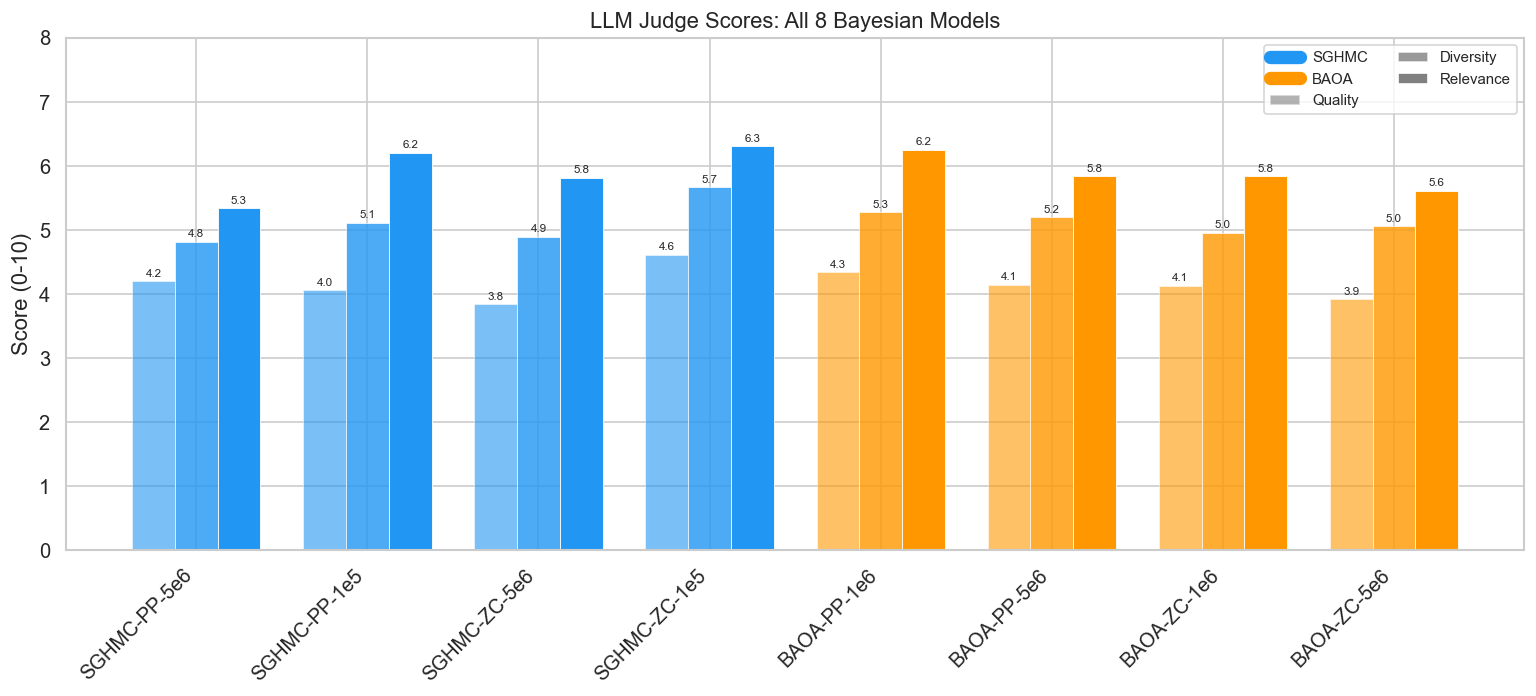

In [25]:
# Cell 4: LLM Judge — All 8 models bar chart

colors_sampler = {'SGHMC': '#2196F3', 'BAOA': '#FF9800'}

fig_dir = PROJECT_ROOT / 'results/evaluation/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_llm))
width = 0.25

for i, metric in enumerate(metrics):
    bar_colors = [colors_sampler[s] for s in df_llm['sampler']]
    alphas = [0.6, 0.8, 1.0][i]
    bars = ax.bar(x + i * width, df_llm[metric], width, alpha=alphas,
                  color=bar_colors, edgecolor='white', linewidth=0.5)
    # Value labels on bars
    for bar, val in zip(bars, df_llm[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_ylabel('Score (0-10)')
ax.set_title('LLM Judge Scores: All 8 Bayesian Models')
ax.set_xticks(x + width)
ax.set_xticklabels(df_llm['label'], rotation=45, ha='right')
ax.set_ylim(0, 8)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors_sampler['SGHMC'], lw=8, label='SGHMC'),
    Line2D([0], [0], color=colors_sampler['BAOA'], lw=8, label='BAOA'),
    mpatches.Patch(alpha=0.6, fc='gray', label='Quality'),
    mpatches.Patch(alpha=0.8, fc='gray', label='Diversity'),
    mpatches.Patch(alpha=1.0, fc='gray', label='Relevance'),
]
ax.legend(handles=legend_elements, loc='upper right', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / 'llm_judge_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

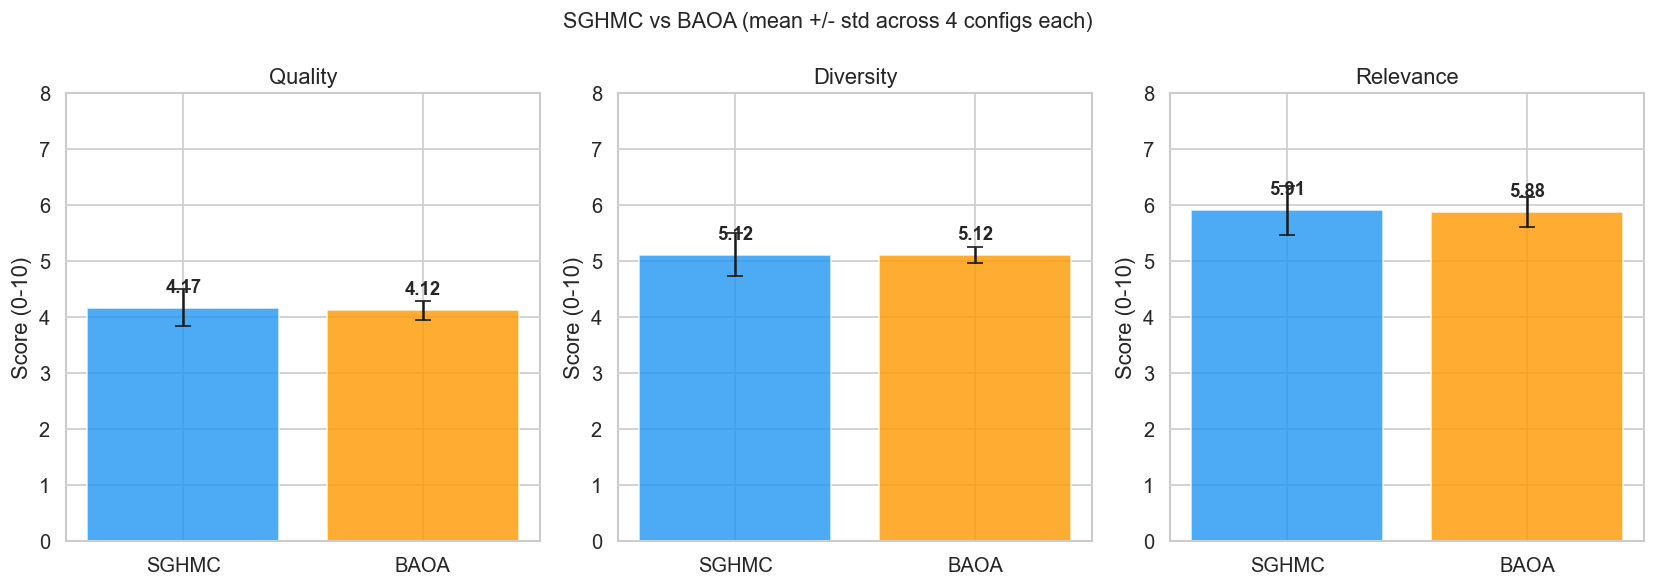


Sampler statistics:


quality        diversity        relevance       
           mean    std      mean    std      mean    std
sampler                                                 
BAOA      4.125  0.172     5.115  0.143      5.88  0.268
SGHMC     4.170  0.329     5.118  0.383      5.91  0.441

In [26]:
# Cell 5: LLM Judge — Sampler comparison (SGHMC vs BAOA)

sampler_stats = df_llm.groupby('sampler')[metrics].agg(['mean', 'std']).round(3)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(metrics):
    ax = axes[i]
    samplers = ['SGHMC', 'BAOA']
    means = [sampler_stats.loc[s, (metric, 'mean')] for s in samplers]
    stds = [sampler_stats.loc[s, (metric, 'std')] for s in samplers]

    bars = ax.bar(samplers, means, yerr=stds, capsize=5,
                  color=[colors_sampler[s] for s in samplers], alpha=0.8, edgecolor='white')

    ax.set_title(metric.capitalize())
    ax.set_ylabel('Score (0-10)')
    ax.set_ylim(0, 8)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{m:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle('SGHMC vs BAOA (mean +/- std across 4 configs each)', fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / 'sampler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSampler statistics:')
display(sampler_stats)

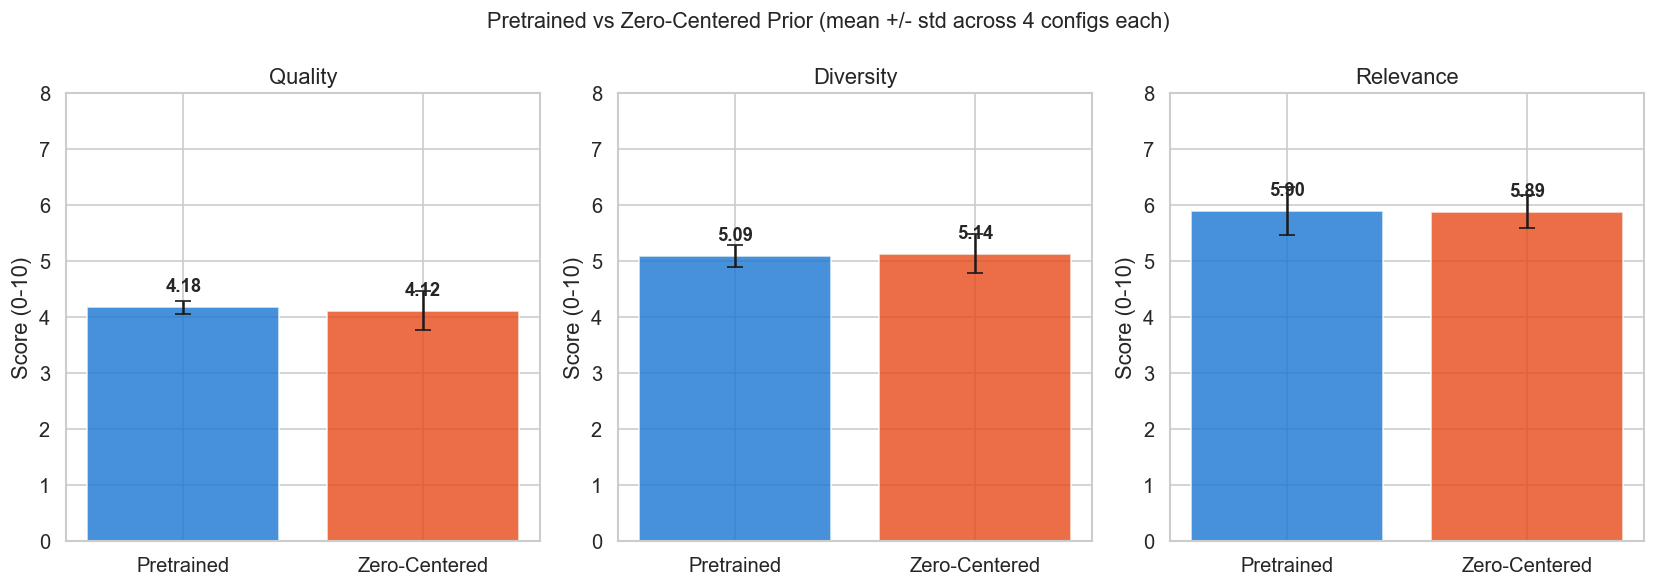


Prior statistics:


quality        diversity        relevance       
                 mean    std      mean    std      mean    std
prior                                                         
pretrained      4.178  0.117     5.095  0.201     5.902  0.425
zero-centered   4.118  0.350     5.138  0.355     5.888  0.292

In [27]:
# Cell 6: LLM Judge — Prior type comparison

prior_stats = df_llm.groupby('prior')[metrics].agg(['mean', 'std']).round(3)
prior_colors = {'pretrained': '#1976D2', 'zero-centered': '#E64A19'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(metrics):
    ax = axes[i]
    priors = ['pretrained', 'zero-centered']
    means = [prior_stats.loc[p, (metric, 'mean')] for p in priors]
    stds = [prior_stats.loc[p, (metric, 'std')] for p in priors]

    bars = ax.bar(['Pretrained', 'Zero-Centered'], means, yerr=stds, capsize=5,
                  color=[prior_colors[p] for p in priors], alpha=0.8, edgecolor='white')

    ax.set_title(metric.capitalize())
    ax.set_ylabel('Score (0-10)')
    ax.set_ylim(0, 8)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{m:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle('Pretrained vs Zero-Centered Prior (mean +/- std across 4 configs each)', fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / 'prior_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPrior statistics:')
display(prior_stats)

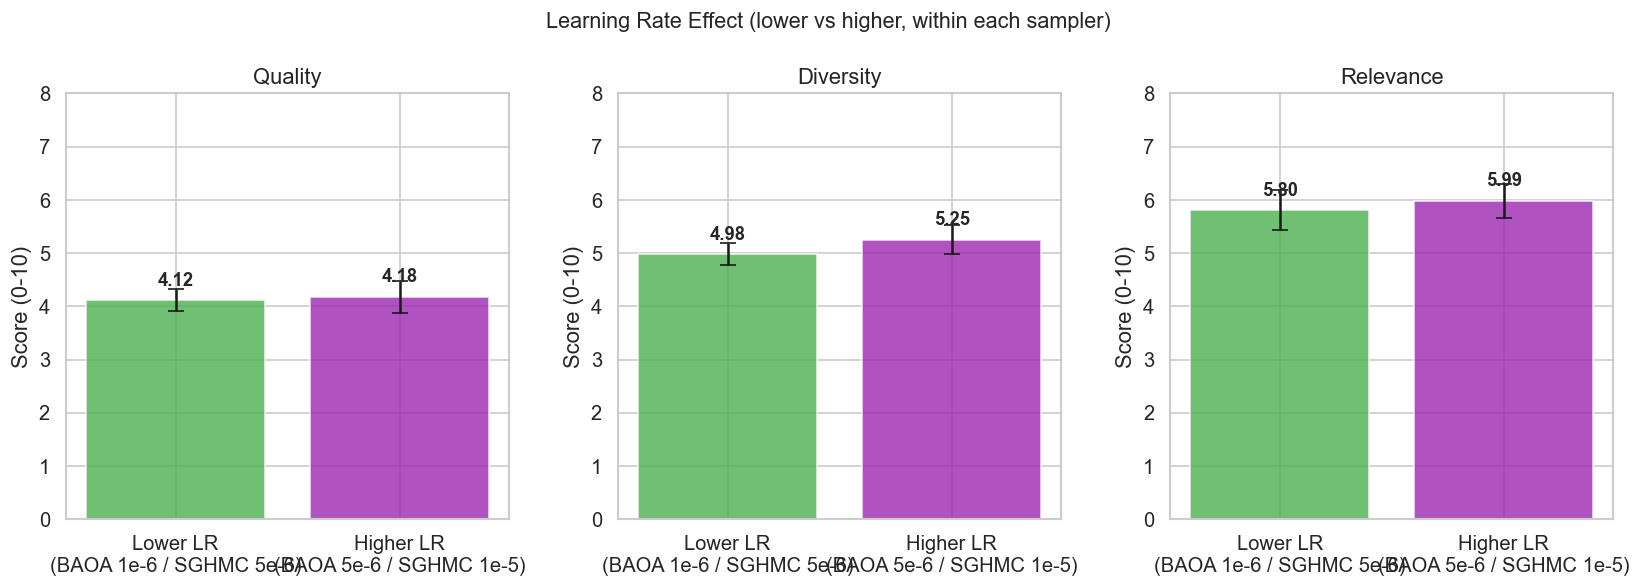


LR category statistics:


quality        diversity        relevance       
               mean    std      mean    std      mean    std
lr_category                                                 
higher        4.178  0.303     5.252  0.278     5.985  0.322
lower         4.118  0.211     4.980  0.202     5.805  0.376


Per-sampler LR effect:

  SGHMC:
    quality: lower=4.01, higher=4.33, diff=+0.32
    diversity: lower=4.85, higher=5.38, diff=+0.54
    relevance: lower=5.57, higher=6.25, diff=+0.68

  BAOA:
    quality: lower=4.22, higher=4.03, diff=-0.20
    diversity: lower=5.11, higher=5.12, diff=+0.01
    relevance: lower=6.04, higher=5.72, diff=-0.32


In [28]:
# Cell 7: LLM Judge — Learning rate effect

# Compare lower vs higher LR within each sampler
lr_stats = df_llm.groupby('lr_category')[metrics].agg(['mean', 'std']).round(3)
lr_colors = {'lower': '#4CAF50', 'higher': '#9C27B0'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(metrics):
    ax = axes[i]
    cats = ['lower', 'higher']
    means = [lr_stats.loc[c, (metric, 'mean')] for c in cats]
    stds = [lr_stats.loc[c, (metric, 'std')] for c in cats]
    lr_labels = ['Lower LR\n(BAOA 1e-6 / SGHMC 5e-6)', 'Higher LR\n(BAOA 5e-6 / SGHMC 1e-5)']

    bars = ax.bar(lr_labels, means, yerr=stds, capsize=5,
                  color=[lr_colors[c] for c in cats], alpha=0.8, edgecolor='white')

    ax.set_title(metric.capitalize())
    ax.set_ylabel('Score (0-10)')
    ax.set_ylim(0, 8)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{m:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle('Learning Rate Effect (lower vs higher, within each sampler)', fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / 'lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nLR category statistics:')
display(lr_stats)

# Also show per-sampler LR effect
print('\nPer-sampler LR effect:')
for sampler in ['SGHMC', 'BAOA']:
    sub = df_llm[df_llm['sampler'] == sampler]
    lo = sub[sub['lr_category'] == 'lower'][metrics].mean()
    hi = sub[sub['lr_category'] == 'higher'][metrics].mean()
    print(f'\n  {sampler}:')
    for m in metrics:
        diff = hi[m] - lo[m]
        print(f'    {m}: lower={lo[m]:.2f}, higher={hi[m]:.2f}, diff={diff:+.2f}')

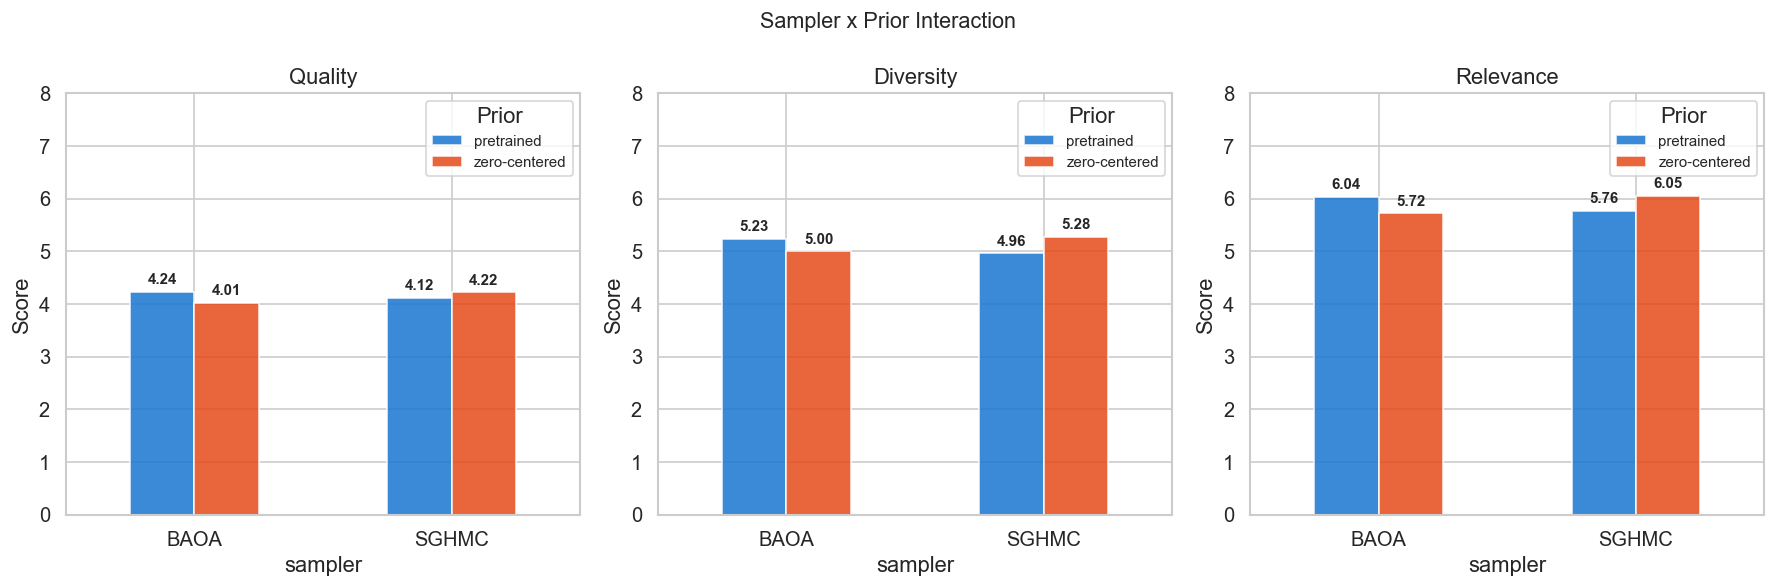


Sampler x Prior means:


quality  diversity  relevance
sampler prior                                       
BAOA    pretrained       4.235      5.230      6.040
        zero-centered    4.015      5.000      5.720
SGHMC   pretrained       4.120      4.960      5.765
        zero-centered    4.220      5.275      6.055

In [29]:
# Cell 7b: LLM Judge — Sampler x Prior interaction

interaction = df_llm.groupby(['sampler', 'prior'])[metrics].mean().round(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(metrics):
    ax = axes[i]
    pivot = interaction[metric].unstack()
    pivot.plot(kind='bar', ax=ax, color=[prior_colors['pretrained'], prior_colors['zero-centered']],
              alpha=0.85, edgecolor='white', rot=0)
    ax.set_title(metric.capitalize())
    ax.set_ylabel('Score')
    ax.set_ylim(0, 8)
    ax.legend(title='Prior', fontsize=9)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=9, fontweight='bold', padding=3)

fig.suptitle('Sampler x Prior Interaction', fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / 'sampler_prior_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSampler x Prior means:')
display(interaction)

In [30]:
# Cell 8: Automated Metrics — Bar charts (if available)

if not df_auto.empty:
    # Average across splits per model
    df_auto_avg = df_auto.groupby(['label', 'sampler', 'prior'])[['bleu', 'rouge2', 'perplexity']].mean().reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for i, (metric, title, lower_better) in enumerate([
        ('bleu', 'BLEU', False),
        ('rouge2', 'ROUGE-2', False),
        ('perplexity', 'Perplexity', True),
    ]):
        ax = axes[i]
        bar_colors = [colors_sampler[s] for s in df_auto_avg['sampler']]
        bars = ax.bar(range(len(df_auto_avg)), df_auto_avg[metric],
                      color=bar_colors, alpha=0.8, edgecolor='white')
        ax.set_xticks(range(len(df_auto_avg)))
        ax.set_xticklabels(df_auto_avg['label'], rotation=45, ha='right', fontsize=9)
        ylabel = f'{title} (lower = better)' if lower_better else title
        ax.set_title(title)
        ax.set_ylabel(ylabel)

        for bar, val in zip(bars, df_auto_avg[metric]):
            fmt = f'{val:.4f}' if metric != 'perplexity' else f'{val:.1f}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    fmt, ha='center', va='bottom', fontsize=8)

    fig.suptitle('Automated Metrics (avg across train/val splits)', fontsize=13)
    plt.tight_layout()
    plt.savefig(fig_dir / 'auto_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No automated metrics data yet. Copy automated_metrics_v2.json from Drive and re-run.')

No automated metrics data yet. Copy automated_metrics_v2.json from Drive and re-run.


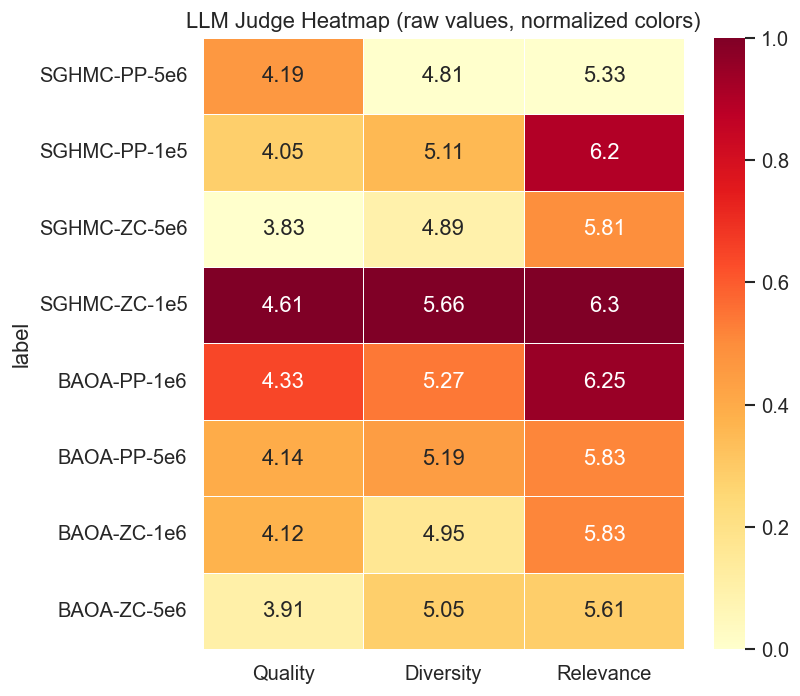

In [31]:
# Cell 9: Heatmap — LLM judge scores

df_heat = df_llm[['label', 'quality', 'diversity', 'relevance']].set_index('label')
df_norm = (df_heat - df_heat.min()) / (df_heat.max() - df_heat.min())

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df_norm, annot=df_heat.round(2).values, fmt='', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            xticklabels=['Quality', 'Diversity', 'Relevance'])
ax.set_title('LLM Judge Heatmap (raw values, normalized colors)')
plt.tight_layout()
plt.savefig(fig_dir / 'llm_judge_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Cell 10: Key findings

sampler_means = df_llm.groupby('sampler')[metrics].mean()
prior_means = df_llm.groupby('prior')[metrics].mean()
lr_means = df_llm.groupby('lr_category')[metrics].mean()
best_overall = df_llm.loc[df_llm['avg_score'].idxmax()]

print('='*70)
print('KEY FINDINGS')
print('='*70)

print('\n--- Best Model per Metric ---')
for metric in metrics:
    best = df_llm.loc[df_llm[metric].idxmax()]
    print(f'  {metric:>10s}: {best["label"]:>16s} ({best[metric]:.2f})')
print(f'  {"overall":>10s}: {best_overall["label"]:>16s} ({best_overall["avg_score"]:.2f})')

print('\n--- SGHMC vs BAOA ---')
for metric in metrics:
    s, b = sampler_means.loc['SGHMC', metric], sampler_means.loc['BAOA', metric]
    w = 'SGHMC' if s > b else 'BAOA'
    print(f'  {metric:>10s}: SGHMC={s:.2f}  BAOA={b:.2f}  -> {w} (+{abs(s-b):.2f})')

print('\n--- Pretrained vs Zero-Centered ---')
for metric in metrics:
    p, z = prior_means.loc['pretrained', metric], prior_means.loc['zero-centered', metric]
    w = 'Pretrained' if p > z else 'Zero-Centered'
    print(f'  {metric:>10s}: PP={p:.2f}  ZC={z:.2f}  -> {w} (+{abs(p-z):.2f})')

print('\n--- Learning Rate Effect (higher vs lower within each sampler) ---')
for metric in metrics:
    lo, hi = lr_means.loc['lower', metric], lr_means.loc['higher', metric]
    w = 'Higher' if hi > lo else 'Lower'
    print(f'  {metric:>10s}: lower={lo:.2f}  higher={hi:.2f}  -> {w} ({hi-lo:+.2f})')

print('\n--- Effect Size Comparison ---')
sampler_effect = abs(sampler_means.loc['SGHMC'].mean() - sampler_means.loc['BAOA'].mean())
prior_effect = abs(prior_means.loc['pretrained'].mean() - prior_means.loc['zero-centered'].mean())
lr_effect = abs(lr_means.loc['lower'].mean() - lr_means.loc['higher'].mean())
print(f'  Sampler effect (SGHMC vs BAOA):        {sampler_effect:.3f}')
print(f'  Prior effect (PP vs ZC):               {prior_effect:.3f}')
print(f'  Learning rate effect (lower vs higher): {lr_effect:.3f}')
largest = 'Learning rate' if lr_effect > max(sampler_effect, prior_effect) else ('Prior' if prior_effect > sampler_effect else 'Sampler')
print(f'  -> Largest factor: {largest}')

if not df_auto.empty:
    print('\n--- Automated Metrics Summary ---')
    auto_summary = df_auto.groupby(['label', 'sampler'])[['bleu', 'rouge2', 'perplexity']].mean()
    display(auto_summary.round(4))

KEY FINDINGS

--- Best Model per Metric ---
     quality:     SGHMC-ZC-1e5 (4.61)
   diversity:     SGHMC-ZC-1e5 (5.66)
   relevance:     SGHMC-ZC-1e5 (6.30)
     overall:     SGHMC-ZC-1e5 (5.52)

--- SGHMC vs BAOA ---
     quality: SGHMC=4.17  BAOA=4.12  -> SGHMC (+0.04)
   diversity: SGHMC=5.12  BAOA=5.12  -> SGHMC (+0.00)
   relevance: SGHMC=5.91  BAOA=5.88  -> SGHMC (+0.03)

--- Pretrained vs Zero-Centered ---
     quality: PP=4.18  ZC=4.12  -> Pretrained (+0.06)
   diversity: PP=5.09  ZC=5.14  -> Zero-Centered (+0.04)
   relevance: PP=5.90  ZC=5.89  -> Pretrained (+0.01)

--- Learning Rate Effect (higher vs lower within each sampler) ---
     quality: lower=4.12  higher=4.18  -> Higher (+0.06)
   diversity: lower=4.98  higher=5.25  -> Higher (+0.27)
   relevance: lower=5.80  higher=5.99  -> Higher (+0.18)

--- Effect Size Comparison ---
  Sampler effect (SGHMC vs BAOA):        0.026
  Prior effect (PP vs ZC):               0.011
  Learning rate effect (lower vs higher): 0.171
  ->

In [33]:
# Cell 11: Generate Markdown report

report = f"""# Bayesian SGMCMC Evaluation Report

## Setup

- **Models**: 8 Bayesian models in a 2x2x2 design
  - **Samplers**: SGHMC, BAOA
  - **Priors**: Pretrained-centered, Zero-centered
  - **Learning rates**: Lower (BAOA 1e-6 / SGHMC 5e-6), Higher (BAOA 5e-6 / SGHMC 1e-5)
- **Architecture**: NanoGPT (10.65M params, 6 layers, 6 heads, 384 embed, char-level Shakespeare)
- **LLM Judge**: Qwen2.5-7B-Instruct scoring quality, diversity, relevance (0-10)
- **Automated**: BLEU, ROUGE, internal perplexity via BMA over posterior samples

## LLM Judge Results

| Model | Sampler | Prior | LR | Quality | Diversity | Relevance | Avg |
|-------|---------|-------|----|---------|-----------|-----------|-----|
"""

for _, row in df_llm.sort_values('avg_score', ascending=False).iterrows():
    report += f"| {row['label']} | {row['sampler']} | {row['prior']} | {row['lr']:.0e} | {row['quality']:.2f} | {row['diversity']:.2f} | {row['relevance']:.2f} | {row['avg_score']:.2f} |\n"

report += f"""
![LLM Judge — All Models](figures/llm_judge_all_models.png)

![LLM Judge Heatmap](figures/llm_judge_heatmap.png)

### SGHMC vs BAOA

| Metric | SGHMC | BAOA | Winner |
|--------|-------|------|--------|
"""
for metric in metrics:
    s, b = sampler_means.loc['SGHMC', metric], sampler_means.loc['BAOA', metric]
    w = 'SGHMC' if s > b else 'BAOA'
    report += f"| {metric.capitalize()} | {s:.2f} | {b:.2f} | **{w}** |\n"

report += f"""
![Sampler Comparison](figures/sampler_comparison.png)

### Pretrained vs Zero-Centered Prior

| Metric | Pretrained | Zero-Centered | Winner |
|--------|------------|---------------|--------|
"""
for metric in metrics:
    p, z = prior_means.loc['pretrained', metric], prior_means.loc['zero-centered', metric]
    w = 'Pretrained' if p > z else 'Zero-Centered'
    report += f"| {metric.capitalize()} | {p:.2f} | {z:.2f} | **{w}** |\n"

report += f"""
![Prior Comparison](figures/prior_comparison.png)

### Learning Rate Effect

Each sampler was tested at two learning rates. "Lower" = BAOA 1e-6 / SGHMC 5e-6; "Higher" = BAOA 5e-6 / SGHMC 1e-5.

| Metric | Lower LR | Higher LR | Winner |
|--------|----------|-----------|--------|
"""
for metric in metrics:
    lo, hi = lr_means.loc['lower', metric], lr_means.loc['higher', metric]
    w = 'Higher' if hi > lo else 'Lower'
    report += f"| {metric.capitalize()} | {lo:.2f} | {hi:.2f} | **{w}** |\n"

report += f"""
![Learning Rate Comparison](figures/lr_comparison.png)

### Sampler x Prior Interaction

![Sampler x Prior Interaction](figures/sampler_prior_interaction.png)
"""

if not df_auto.empty:
    auto_avg = df_auto.groupby(['label', 'sampler'])[['bleu', 'rouge2', 'perplexity']].mean().reset_index()
    report += f"""
## Automated Metrics

| Model | BLEU | ROUGE-2 | Perplexity |
|-------|------|---------|------------|
"""
    for _, row in auto_avg.iterrows():
        report += f"| {row['label']} | {row['bleu']:.4f} | {row['rouge2']:.4f} | {row['perplexity']:.1f} |\n"

    report += f"""
![Automated Metrics](figures/auto_metrics_comparison.png)
"""

report += f"""
## Key Findings

1. **Best model**: {best_overall['label']} (avg {best_overall['avg_score']:.2f}/10)
2. **Learning rate is the dominant factor**: Effect size {lr_effect:.3f} vs sampler {sampler_effect:.3f} vs prior {prior_effect:.3f}. Higher LR consistently improves diversity and relevance.
3. **SGHMC vs BAOA**: Nearly identical on average ({sampler_means.loc['SGHMC'].mean():.2f} vs {sampler_means.loc['BAOA'].mean():.2f}). Sampler choice has minimal impact.
4. **Prior type**: Pretrained and zero-centered priors perform similarly ({prior_means.loc['pretrained'].mean():.2f} vs {prior_means.loc['zero-centered'].mean():.2f}). Prior choice has the smallest effect.
5. **Practical implication**: Tuning the learning rate matters more than choosing between SGHMC/BAOA or pretrained/zero-centered priors.

---
*Generated from `notebooks/analysis_report.ipynb`*
"""

report_path = PROJECT_ROOT / 'results/evaluation/evaluation_report.md'
with open(report_path, 'w') as f:
    f.write(report)
print(f'Saved to {report_path}\n')
print(report)

Saved to C:\Users\hayk_\OneDrive\Desktop\05_LMU_Masters\04_applied_dl\adl_last\adl-bnn-textgen\results\evaluation\evaluation_report.md

# Bayesian SGMCMC Evaluation Report

## Setup

- **Models**: 8 Bayesian models in a 2x2x2 design
  - **Samplers**: SGHMC, BAOA
  - **Priors**: Pretrained-centered, Zero-centered
  - **Learning rates**: Lower (BAOA 1e-6 / SGHMC 5e-6), Higher (BAOA 5e-6 / SGHMC 1e-5)
- **Architecture**: NanoGPT (10.65M params, 6 layers, 6 heads, 384 embed, char-level Shakespeare)
- **LLM Judge**: Qwen2.5-7B-Instruct scoring quality, diversity, relevance (0-10)
- **Automated**: BLEU, ROUGE, internal perplexity via BMA over posterior samples

## LLM Judge Results

| Model | Sampler | Prior | LR | Quality | Diversity | Relevance | Avg |
|-------|---------|-------|----|---------|-----------|-----------|-----|
| SGHMC-ZC-1e5 | SGHMC | zero-centered | 1e-05 | 4.61 | 5.66 | 6.30 | 5.52 |
| BAOA-PP-1e6 | BAOA | pretrained | 1e-06 | 4.33 | 5.27 | 6.25 | 5.28 |
| SGHMC-PP-1e5 | SG